이 파일은 평가를 위해 답변을 엑셀로 저장하는 용도로 수정되었습니다. \
로그 저장 기능을 전부 삭제하였습니다. \
100$ 충전된 OpenAI를 사용합니다.

In [31]:
import os
import logging
from logging.handlers import RotatingFileHandler
import json
from pymongo import MongoClient
from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
from typing import Literal, TypedDict, List
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.schema import Document
from langchain_community.retrievers import BM25Retriever
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langchain.retrievers import EnsembleRetriever
from langgraph.graph import StateGraph, START, END
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.retrievers import ContextualCompressionRetriever
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [32]:
# 환경 변수 로드
load_dotenv()

# 로거 설정
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
console_handler = logging.StreamHandler()
logger.addHandler(console_handler)

In [33]:
#----1. 모델 정의----
model = ChatOpenAI(
    model_name='gpt-4o',
    temperature=0.5
)

In [34]:
#----2. State 정의----
class State(TypedDict):
    session_id: str
    conversation_count: int
    default_count: int
    input_msg: str
    initial_translated: str #Eng #rewrite 하면 여기로 저장됨
    route: str
    source: str
    documents: List[str]
    generation: str
    final_translated: str #Persian

In [35]:
#----3. RAG 설정 (미리 로드)----
from langchain.text_splitter import RecursiveCharacterTextSplitter
# Chroma DB 경로
persist_directory = "./chroma_db"

docs = []
data_folder = 'data' # 루트 데이터 폴더

print(f"'{data_folder}'에서 데이터 로드 시작...")

# os.walk를 사용하여 'data' 폴더와 모든 하위 폴더(gq, book)를 탐색
for dirpath, _, filenames in os.walk(data_folder):
    for file_name in filenames:
        file_path = os.path.join(dirpath, file_name)
        file_name_lower = file_name.lower()
        
        # 1. 엑셀 파일 처리 (기존 로직)
        if file_name_lower.endswith(('.xlsx', '.xls')):
            try:
                df = pd.read_excel(file_path)
                print(f"  [Excel] 로드: {file_path}")

                title_column = None
                if 'big_title_eng' in df.columns:
                    title_column = 'big_title_eng'
                elif 'big_title_ara' in df.columns:
                    title_column = 'big_title_ara'

                for index, row in df.iterrows():
                    content = f"질문: {row.get('Question_ENG', '')}\n\n답변: {row.get('Answer_ENG', '')}"
                    metadata = {
                        # URL_ENG가 없으면 파일 경로를 source로 사용
                        "source": row.get('URL_ENG', file_path), 
                        "row_number": index + 1
                    }
                    
                    # 카테고리 설정: 1순위 엑셀 컬럼, 2순위 하위 폴더명
                    if title_column and pd.notna(row.get(title_column)):
                        metadata["category"] = row.get(title_column)
                    else:
                        metadata["category"] = os.path.basename(dirpath) # 예: 'gq'

                    docs.append(Document(page_content=content, metadata=metadata))
            except Exception as e:
                print(f"  [Error] 엑셀 파일 처리 중 오류 {file_path}: {e}")

        # 2. 텍스트 파일 처리 (새로운 로직)
        elif file_name_lower.endswith('.txt'):
            try:
                # 텍스트 파일 인코딩은 'utf-8'로 가정 (환경에 따라 다를 수 있음)
                with open(file_path, 'r', encoding='utf-8') as f:
                    content = f.read()
                print(f"  [Text] 로드: {file_path}")
                
                metadata = {
                    "source": file_path,
                    "category": os.path.basename(dirpath) # 예: 'book'
                }
                docs.append(Document(page_content=content, metadata=metadata))
            except Exception as e:
                print(f"  [Error] 텍스트 파일 처리 중 오류 {file_path}: {e}")

print(f"총 {len(docs)}개의 문서를 로드했습니다.")


embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Chroma DB 존재 여부 확인 및 처리 
if os.path.exists(persist_directory) and len(os.listdir(persist_directory)) > 0:
    print("기존 Chroma DB 로드")
    # [중요] 기존 DB를 로드할 때도 embedding_function을 꼭 넣어줘야 검색이 가능합니다.
    chroma_db = Chroma(
        persist_directory=persist_directory,
        embedding_function=embeddings 
    )
else:
    print("새로운 Chroma DB 생성 및 저장")
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
    split_docs = text_splitter.split_documents(docs)
    print(f"청크 후 문서 개수: {len(split_docs)}")

    # from_documents를 사용하면 persist_directory가 지정된 경우 자동 저장됩니다.
    chroma_db = Chroma.from_documents(
        documents=split_docs,
        embedding=embeddings,
        persist_directory=persist_directory
    )


# Retriever 설정
chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 10})
bm25_retriever = BM25Retriever.from_documents(docs)
ensemble_retriever = EnsembleRetriever(
    retrievers=[chroma_retriever, bm25_retriever],
    weights=[0.5, 0.5]
)

# Re-ranking
llm_compressor = ChatOpenAI(model_name='gpt-4o', temperature=0.5)
compressor = LLMChainExtractor.from_llm(llm_compressor)

compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=ensemble_retriever
)
print("RAG 설정 완료.")

'data'에서 데이터 로드 시작...
  [Text] 로드: data/book/book9_en.txt
  [Text] 로드: data/book/book5_en.txt
  [Text] 로드: data/book/book7_en.txt
  [Text] 로드: data/book/book3_en.txt
  [Text] 로드: data/book/book10_en.txt
  [Text] 로드: data/book/book12_en.txt
  [Text] 로드: data/book/book1_en.txt
  [Text] 로드: data/book/book8_en.txt
  [Text] 로드: data/book/book4_en.txt
  [Text] 로드: data/book/book6_en.txt
  [Text] 로드: data/book/book11_en.txt
  [Text] 로드: data/book/book2_en.txt
  [Text] 로드: data/book/book13_en.txt
  [Excel] 로드: data/gq/GotQuestions_raw_Ara_2025-05-01.xlsx
총 2191개의 문서를 로드했습니다.
기존 Chroma DB 로드
RAG 설정 완료.


In [36]:
def serialize_state(obj):
    if isinstance(obj, Document):
        return {
            "id": obj.id,
            "metadata": obj.metadata,
            "page_content": obj.page_content
        }
    elif isinstance(obj, list):
        return [serialize_state(o) for o in obj]
    elif isinstance(obj, dict):
        return {k: serialize_state(v) for k, v in obj.items()}
    return obj

In [37]:
#광고 내용 설정
AD_CONTEXT = """
The user initiated this conversation by clicking a link from an advertisement by 'Afghan Christians'.
The user is likely a Persian (Dari) speaker from a Muslim background living in Afghanistan or the region.
(Note: While there are some Pashto speakers, the primary audience is Persian/Dari speaking.)

The advertisement invites users to:
1. Learn about Jesus Christ (Isa al-Masih) through videos and teachings, primarily in Persian (Dari).
2. Find and read the Bible (Injil) in their own language.
3. Participate in online communities, church meetings, or Bible teaching sessions.
4. Request prayer support from brothers and sisters for problems in their lives."""

In [38]:
#----4. 로그 저장 함수----
def append_step_log(state: State, step_name: str, step_output: dict = None):
    """
    파일/DB 저장을 제거하고, 실행 중인 State 메모리에 로그 누적
    """
    
    # 1. 현재 단계 로그 생성
    step_log = {
        "step_name": step_name,
        "timestamp": datetime.now().isoformat(),
        # "state_snapshot": serialize_state(state), 
        "step_output": step_output or {}
    }

    # 2. State에 'log_steps' 키가 없으면 생성
    if "log_steps" not in state:
        state["log_steps"] = []

    # 3. State 리스트에 추가 (메모리 상에만 존재)
    state["log_steps"].append(step_log)

    return state

In [ ]:
#---5. 초기화 노드---
def initialize_turn(state: State) -> State:
    """
    새로운 대화 턴을 위한 상태 초기화
    이전 턴의 documents, generation 등 모두 제거
    """
    
    print(">> INITIALIZE TURN: Clearing state for new input.")
    
    state["documents"] = []
    state["generation"] = ""
    state["initial_translated"] = ""
    state["final_translated"] = ""
    state["route"] = ""
    state["source"] = ""
    
    print("   State cleared. Documents list is now empty.")
    return state

In [40]:

#----5. 번역 노드----
def translate_persian_to_english(state: State) -> State:
    """파슈토어/페르시아어 입력을 영어로 번역"""
    print(">> TRANSLATE INPUT (Pashto/Persian) TO ENGLISH")
    input_msg = state["input_msg"]
    
    system = """
    You are an expert translator.
    The user is likely speaking Pashto or Persian (Dari).
    Translate the input into English appropriately, reflecting the cultural context of Afghanistan and the region.
    If the input is already in English, keep it as is.
    Only return the English translated sentence.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{input_msg}")])
    chain = prompt | model | StrOutputParser()
    
    translated_msg = chain.invoke({"input_msg": input_msg})
    state["initial_translated"] = translated_msg
    
    return append_step_log(state, "translate_persian_to_english", {"initial_translated": translated_msg})

def translate_english_to_persian(state: State) -> State:
    """영어 응답을 파슈토어/페르시아어로 번역"""
    print(">> TRANSLATE ENGLISH TO PASHTO/PERSIAN")
    generation = state.get("generation", "")
    
    system = """
    You are an expert translator.
    Translate the input into the user's language (Pashto or Persian/Dari) appropriately. 
    Reflect the characteristics of the language and the cultural context of Afghanistan.
    Usually, if the user initiated contact via the Pashto ad, reply in Pashto. If unsure, provide the translation that best fits the region.
   
    Strictly output raw plain text only. Do not use any Markdown formatting syntax. 
    Specifically, avoid using asterisks (*), hashes (#), backticks (`), or bullet points. 
    Do not use bold or italics for emphasis.
    
    After translating, insert two line breaks and output the generated English.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{generation}")])
    chain = prompt | model | StrOutputParser()
    
    translated_response = chain.invoke({"generation": generation})
    state["final_translated"] = translated_response

    if translated_response == "":
        return append_step_log(state, "translate_english_to_persian", {"final_translated": None})
    else:
        return append_step_log(state, "translate_english_to_persian", {"final_translated": translated_response})

In [41]:
#----6. 노드 및 체인 정의----
def router(state: State) -> State:
    """대화 횟수를 증가시키고 로그 기록"""
    state["conversation_count"] = state.get("conversation_count", 0) + 1
    
    # 초기 입력일 시 initial 표시 남기기
    """if state["conversation_count"] == 1:
        state = append_step_log(state, "receive_initial_input")"""
    return state

class RouteQuery(BaseModel):
    router: Literal["block", "rag", "default"] = Field(description="Given a user question choose to route it to block, rag or default.")

def route_query(state: State) -> Literal["block", "rag", "default"]:
    """사용자 질문을 라우팅하고 로그 기록"""
    model_with_structured_output = model.with_structured_output(RouteQuery)
    translated_msg = state["initial_translated"]
    conversation_count = state.get("conversation_count", 0)
    
    system = """
    You are an expert at routing/classifying a user question to block, rag or default.
    
    Classification Criteria:
    1. default: General concerns, life problems, relationships, information requiring, irrelevant messages with Christianity, question about the chatbot, etc.
    2. rag: Faith-related questions, religious concerns, spiritual issues, questions about the Bible.
    3. block: Profanity, curses, spam, advertising, inappropriate sexual content, threatening messages.
    
    You must answer only one of these three words.
    """
    
    prompt_router = ChatPromptTemplate.from_messages(
        [
            ("system", system), 
            ("human", "{translated_msg}")
        ]
    )
    
    chain_router = prompt_router | model_with_structured_output
    
    out = chain_router.invoke({"translated_msg": translated_msg})
    
    route = "default"
    if out.router == "block":
        route = "block"
    elif out.router == "rag":
        route = "rag"
    
    print(f">> ROUTE QUESTION TO {route.upper()}")
    state["route"] = route
    return append_step_log(state, "route_query", {"route": route})

def node_default_responser(state: State) -> State:
    """'Default' 주제에 대한 답변을 생성하고 로그 기록하기"""
    print(">> DEFAULT")
    input_msg = state["input_msg"]
    translated_msg = state["initial_translated"]
    default_count = state.get("default_count", 0) + 1 
    
    # 위에서 정의한 광고 맥락을 프롬프트에 포함
    system = f"""
    You are a Christian counselor AI for 'Afghan Christians'.
    {AD_CONTEXT}
    
    You were designed with a deep understanding of Muslims and their background.
    Never rush faith — let love lead the way. Always return to the hope, healing, and dignity we have in Christ.
    
    If the user simply says "Hello" or seems hesitant, warmly welcome them and gently mention the services offered in the ad (Bible, prayer, learning about Jesus) to guide the conversation.
    If the conversation is not progressing towards faith-related topics, respond politely.
    """
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system), 
            ("human", "{translated_msg}")
        ]
    )
    
    chain = prompt | model | StrOutputParser()
    
    if default_count > 3:
        if input_msg == "Can I get more information?":
            result = chain.invoke({"translated_msg": translated_msg})
        else:
            result = "\\n\\nI appreciate our chat! If you have questions about faith or spirituality, I'm here to help."
    else:
        result = chain.invoke({"translated_msg": translated_msg})
    
    state["generation"] = result
    state["default_count"] = default_count
    
    return append_step_log(state, "node_default_responser", {"generation": result})

def node_rag_responser(state: State) -> State:
    """'RAG' 주제에 대한 문서를 검색하고 로그 기록"""
    print(">> RETRIEVE")
    translated_msg = state["initial_translated"]
    documents = compression_retriever.invoke(translated_msg)
    
    state["documents"] = documents
    state["source"] = "vectorstore"

    # 로그에는 문서 개수와 메타데이터만 기록
    doc_summary = [{"page_content_preview": doc.page_content[:100] + "...", "metadata": doc.metadata} for doc in documents]
    return append_step_log(state, "node_rag_responser", {"retrieved_docs_summary": doc_summary})

def node_block_responser(state: State) -> State:
    """'Block' 주제에 대해 응답하지 않고 로그 기록"""
    print(">> BLOCK")
    result = None
    state["generation"] = result
    state["translated_response"] = result
    
    # 새로운 로그 함수 사용
    return append_step_log(state, "node_block_responser", {"generation": result})


def generate(state: State) -> State:
    """RAG 문서를 기반으로 최종 답변을 생성하고 로그 기록"""
    print(">> GENERATE")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    system = """ 
    You are a wise and compassionate pastor with deep knowledge of the Bible and Christian faith.
    You provide spiritual guidance and counsel based on biblical principles.

    Your approach:
    - Use the provided Q&A knowledge base to give accurate biblical answers
    - Speak naturally and conversationally, like a caring friend
    - Keep responses concise and conversational (1-2 sentences typically)
    - Respond like a real person, not an AI assistant
    - Reference relevant Bible verses when appropriate, but briefly
    - Provide practical spiritual guidance in simple terms
    - Show understanding for people's spiritual struggles
    - Always respond in English as the default language
    
    Strictly output raw plain text only. Do not use any Markdown formatting syntax. 
    Specifically, avoid using asterisks (*), hashes (#), backticks (`), or bullet points. 
    Do not use bold or italics for emphasis.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{translated_msg}")])
    chain_rag = prompt | model | StrOutputParser()
    
    out = chain_rag.invoke({"context": documents, "translated_msg": translated_msg})
    state["generation"] = out
    state["final_translated"] = out
    
    return append_step_log(state, "generate_rag_response", {"generation": out})

def rewrite_query(state: State):
    print(">> REWRITE QUERY")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    system = """
    You are a question re-writer that converts an input question to a better version that is optimized for vectorstore retrieval. 
    Look at the input and try to reason about the underlying semantic intent.
    Rewrite the question, maintaining the original intent and preserving the original words as much as possible.
    """
    
    prompt_rewriter = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Here is the initial question: \n\n {question}."),
        ]
    )

    chain_rewriter = prompt_rewriter | model | StrOutputParser()
    
    new_question = chain_rewriter.invoke(
        {
            "question": translated_msg
        }
    )
    
    state["initial_translated"] = new_question
    return append_step_log(state, "rewrite_query", {"new_question": new_question})

class Relevancy(BaseModel):
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

def judge_retrieval(state: State):
    print(">> JUDGE RELEVANCE OF THE RETRIEVED DOCUMENTS")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    model_with_structured_output = model.with_structured_output(Relevancy)
    
    system = """
    You are a judge assessing relevance of a retrieved document to a user translated_msg.
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """
    
    prompt_retrieval_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Retrieved document: \n\n {document} \n\n User question: {translated_msg}")
        ]
    )
    
    chain_grade = prompt_retrieval_judge | model_with_structured_output
    
    filtered_docs = []
    for doc in documents:
        out = chain_grade.invoke(
            {
                "translated_msg": translated_msg,
                "document": doc.page_content
            }
        )
        
        if out.binary_score == "yes":
            print("    >> DECISION: DOCUMENT RELEVANT")
            filtered_docs.append(doc)
        else:
            print("    >> DECISION: DOCUMENT IRRELEVANT")
    
    state["documents"] = filtered_docs
    return append_step_log(state, "judge_retrieval", {"filtered_docs": [doc.metadata for doc in filtered_docs]})

class Factfulness(BaseModel):
    reasoning: str = Field( #추가됨
        description="The step-by-step reasoning process to determine if the generation is grounded in the facts."
    )
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

class Addressed(BaseModel):
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

def judge_answer(state: State):
    print(">> CHECK IF ANSWER ADDRESSES/RESOLVES THE QUESTION")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    generation = state["generation"]
    
    
    system ="""
    You are a grader assessing whether an LLM's response is relevant and appropriate for the user's input.
    The user's input might be a question, a statement, or a command.
    Your job is to determine if the LLM's response is a reasonable and relevant reaction.
    Give a binary score 'yes' or 'no'. 'Yes' means the response is relevant and appropriate.
    """

    prompt_answer_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "User question: \n\n {translated_msg} \n\n LLM generation: {generation}")
        ]
    )
    

    model_with_structured_output = model.with_structured_output(Addressed)

    chain_answer = prompt_answer_judge | model_with_structured_output
    
    out = chain_answer.invoke(
        {
            "translated_msg": translated_msg,
            "generation": generation
        }
    )
    
    print(f"     >> DECISION: {out.binary_score.upper()}")
    
    return out.binary_score

def judge_factfullness(state: State) -> Literal["resolved", "not resolved", "hallucinating"]:
    print(">> CHECK HALLUCINATION")
    documents = state["documents"]
    generation = state["generation"]
    
    # 단계별로 생각하라는 지침 추가
    system = """
    You are a judge assessing if an LLM's generation is thematically consistent with a set of retrieved documents.
    First, provide a step-by-step reasoning to compare the generation with the provided facts.
    Explain whether the generation is a direct quote, a summary, a logical inference, or a statement that aligns with the documents.
    After your reasoning, give a final binary score 'yes' or 'no'. 'Yes' means the generation is consistent with or logically follows from the provided documents.
    Don't forget you are the judger of the generation of Christian chatbot.
    """
    
    prompt_hallucination_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}")
        ]
    )
    
    
    model_with_structured_output = model.with_structured_output(Factfulness)
    
    chain_hallucination = prompt_hallucination_judge | model_with_structured_output
    
    out = chain_hallucination.invoke({"documents": documents, "generation": generation})
    
    #기존 코드
    """model_with_structured_output = model.with_structured_output(Factfulness)
    
    chain_hallucination = prompt_hallucination_judge | model_with_structured_output
    
    out = chain_hallucination.invoke({"documents": documents, "generation": generation})
    """
    
    # 모델의 생각의 연쇄(reasoning) 과정 출력하여 사고 과정 확인
    print(f"     >> Reasoning: {out.reasoning}")
    
    if out.binary_score == "yes":
        print("    >> DECISION: FACTFUL")
        
        is_answering = judge_answer(state)
        if is_answering == "yes":
            return "resolved"
        else:
            return "not resolved"
    else:
        print("    >> DECISION: HALLUCINATING")
        return "hallucinating"

def generate_or_rewrite_query(state: State) -> Literal["generate", "rewrite_query"]:
    print(">> HAS RELEVANT DOCS?")
    filtered_docs = state["documents"]
    
    if len(filtered_docs) > 0:
        print("    >> DECISION: GENERATE")
        return "generate"
    else: 
        print("    >> DECISION: REWRITE QUERY")
        return "rewrite_query"


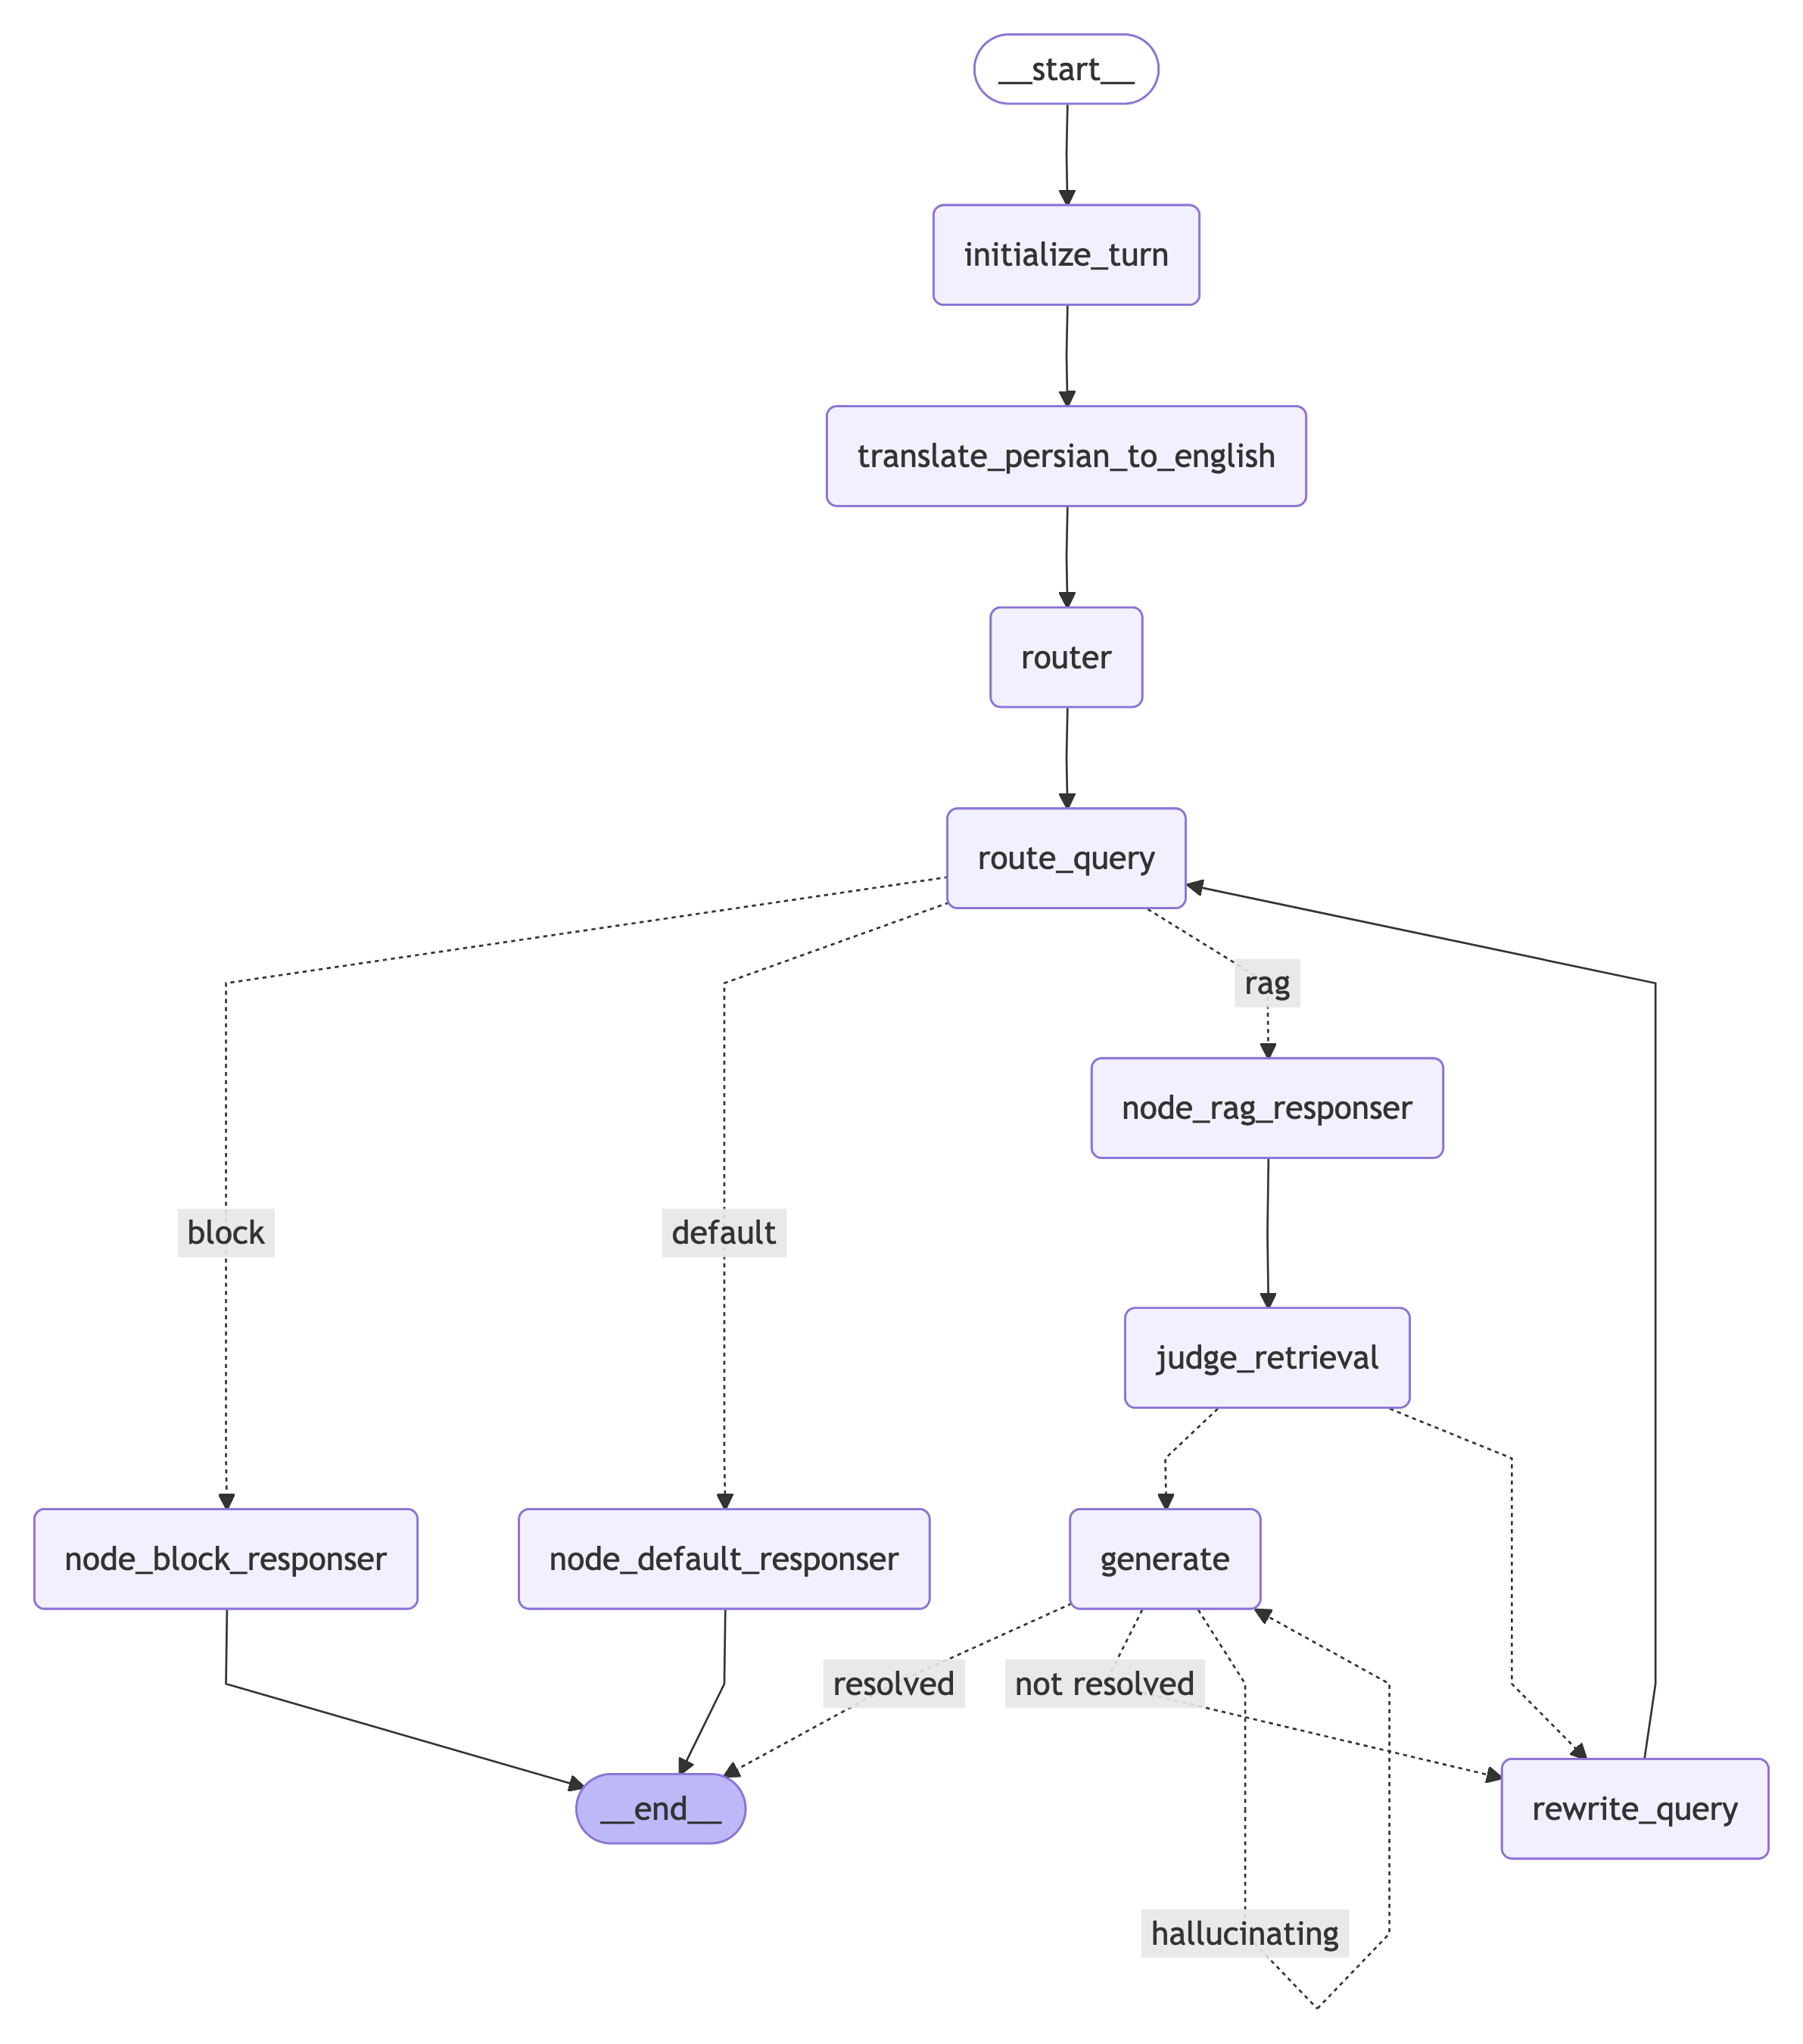

'diagram = Image(\n    graph.get_graph().draw_mermaid_png()\n)\ndisplay(diagram)'

In [42]:
#----7. 그래프 생성 및 컴파일----
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod
import nest_asyncio

nest_asyncio.apply()

memory = MemorySaver()

graph = (
    StateGraph(State)
    .add_node("initialize_turn", initialize_turn)
    .add_node("translate_persian_to_english", translate_persian_to_english)
    .add_node("router", router)
    .add_node("route_query", route_query)
    .add_node("node_rag_responser", node_rag_responser)
    .add_node("node_default_responser", node_default_responser)
    .add_node("node_block_responser", node_block_responser)
    .add_node("generate", generate)
    .add_node("judge_retrieval", judge_retrieval)
    .add_node("rewrite_query", rewrite_query)
    #.add_node("translate_english_to_persian", translate_english_to_persian)
    .add_edge(START, "initialize_turn")
    .add_edge("initialize_turn", "translate_persian_to_english")
    .add_edge("translate_persian_to_english", "router")
    .add_edge("router", "route_query")
    .add_conditional_edges(
        "route_query",
        lambda state: state["route"],
        {
            "rag": "node_rag_responser",
            "default": "node_default_responser",
            "block": "node_block_responser",
        }
    )
    #.add_edge("node_default_responser", "translate_english_to_persian")
    .add_edge("node_default_responser", END)
    .add_edge("node_rag_responser", "judge_retrieval")
    .add_conditional_edges(
        "judge_retrieval",
        generate_or_rewrite_query,
        {
            "generate": "generate",
            "rewrite_query": "rewrite_query"
        }
    )
    .add_edge("rewrite_query", "route_query")
    .add_conditional_edges(
        "generate",
        judge_factfullness,
        {
            "hallucinating": "generate",
            #"resolved": "translate_english_to_persian",
            "resolved": END,
            "not resolved": "rewrite_query"
        }
    )
    #.add_edge("translate_english_to_persian", END)
    .add_edge("node_block_responser", END)
    .compile(checkpointer=memory)
)


#그래프 시각화
from IPython.display import display, Image

diagram = Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER))
display(diagram)

"""diagram = Image(
    graph.get_graph().draw_mermaid_png()
)
display(diagram)"""

In [43]:
def run(input_msg: str, session_id: str):
    """
    파일/DB 로드 없이 그래프만 실행하고 콘솔에 출력
    """
    def clean(text):
        return text.replace("\n", "")[:50] + "..."
    
    conversation_count = 0

    # LangGraph 실행 설정 
    config = RunnableConfig(
        configurable={"thread_id": session_id},
        recursion_limit=20
    )

    # 입력 설정 
    inputs = {
        "input_msg": input_msg,
        "session_id": session_id,
        "conversation_count": conversation_count,
        # "log_steps": [] # 필요시
    }

    try:    
        final_state = {}
        for output in graph.stream(inputs, config):
            for key, value in output.items():
                final_state.update(value)
                
                # --- 콘솔 출력 로깅 ---
                if "input_msg" in value:
                    print(f"     input_msg    : {value['input_msg']}")
                if "documents" in value:
                    for idx, doc in enumerate(value['documents']):
                        print(f"     document    : {clean(doc.page_content)}")
                if "generation" in value:
                    print(f"     generation     : {value['generation']}")
                if "initial_translated" in value:
                    print(f"     initial_translated : {value['initial_translated']}")
                if "source" in value:
                    print(f"     source     : {value['source']}")
                if "route" in value:
                    print(f"     route      : {value['route']}")
                    
        print("\n")
        print("Generation: ", final_state.get("final_translated", final_state.get("generation", "")))
        print("="*100, "\n")
        
    except Exception as e:
        print(f"\n[ERROR] An unexpected error occurred: {e}")

In [ ]:
import pandas as pd
import uuid
import time

# 1. 엑셀 파일 로드 
input_filename = 'GQ_Summarized_Full.xlsx' 
df = pd.read_excel(input_filename)


df = df[['Question', 'Original_Answer', 'Chatbot_Summary']] 

# 3. 값을 반환하는 실행 함수 정의
def get_ai_response(input_msg):
    """
    그래프를 실행하고 결과 텍스트만 반환합니다.
    매번 새로운 session_id를 사용하여 독립적인 답변을 생성합니다.
    """
    session_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": session_id}}
    
    inputs = {
        "input_msg": input_msg,
        "conversation_count": 0
    }
    
    try:
        output = graph.invoke(inputs, config)
        
        # 최종 답변 추출
        answer = output.get("final_translated", output.get("generation", ""))
        return answer
    except Exception as e:
        return f"Error: {str(e)}"

In [45]:
# --- 테스트 실행 코드 (상위 2개만) ---

print(">>> 테스트 실행 시작 (2개 질문)...")

# 상위 2개 행만 복사하여 테스트
df_test = df.head(1).copy()

# 결과 저장을 위한 리스트
ai_answers_1 = []
ai_answers_2 = []
ai_answers_3 = []

for index, row in df_test.iterrows():
    question = row['Question']
    print(f"[{index+1}/{len(df_test)}] 질문 처리 중: {question[:30]}...")
    
    # 3번 반복하여 답변 생성
    ans1 = get_ai_response(question)
    print("   - 답변 1 생성 완료")
    ans2 = get_ai_response(question)
    print("   - 답변 2 생성 완료")
    ans3 = get_ai_response(question)
    print("   - 답변 3 생성 완료")
    
    ai_answers_1.append(ans1)
    ai_answers_2.append(ans2)
    ai_answers_3.append(ans3)

# 데이터프레임에 결과 추가
df_test['AI_Answer1'] = ai_answers_1
df_test['AI_Answer2'] = ai_answers_2
df_test['AI_Answer3'] = ai_answers_3

# 테스트 결과 저장 (엑셀)
df_test.to_excel("chatbot_results_test_2.xlsx", index=False)
print(">>> 테스트 완료! 'chatbot_results_test_2.xlsx' 파일이 저장되었습니다.")

# 결과 미리보기
df_test.head()

>>> 테스트 실행 시작 (2개 질문)...
[1/1] 질문 처리 중: Got Eternal Life?...
>> INITIALIZE TURN: Clearing state for new input.
   State cleared. Documents list is now empty.
>> TRANSLATE INPUT (Pashto/Persian) TO ENGLISH
>> ROUTE QUESTION TO RAG
>> RETRIEVE
>> JUDGE RELEVANCE OF THE RETRIEVED DOCUMENTS
    >> DECISION: DOCUMENT RELEVANT
    >> DECISION: DOCUMENT RELEVANT
>> HAS RELEVANT DOCS?
    >> DECISION: GENERATE
>> GENERATE
>> CHECK HALLUCINATION
     >> Reasoning: 1. The LLM generation states that believers in Jesus Christ are promised eternal life. This aligns with the documents, specifically Document 1, which quotes John 3:16, "whoever believes in him shall not perish but have eternal life."

2. The generation mentions that eternal life is a gift of grace through faith. While this specific phrase "gift of grace through faith" is not directly quoted in the documents, it is a commonly accepted theological interpretation of the verses cited (e.g., John 3:16 and John 11:25-26) and aligns with the

,Question,Original_Answer,Chatbot_Summary,AI_Answer1,AI_Answer2,AI_Answer3
0,Got Eternal Life?,The Bible presents a clear path to eternal lif...,Eternal life is a gift that comes from trustin...,"Yes, as believers in Jesus Christ, we are prom...",Eternal life in Christianity refers to living ...,Eternal life is a gift from God through faith ...


In [ ]:
import pandas as pd
import uuid
import time

# 1. 파일 로드 및 설정
input_filename = 'GQ_Summarized_Full.xlsx'
df = pd.read_excel(input_filename)
df = df[['Question', 'Original_Answer', 'Chatbot_Summary']]

# 2. 안전한 응답 생성 함수 (에러 핸들링)
def get_ai_response_safe(input_msg):
    """
    에러가 발생하면 멈추지 않고 공백 반환
    """
    session_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": session_id}}
    inputs = {"input_msg": input_msg, "conversation_count": 0}
    
    try:
        # 그래프 실행 시도
        output = graph.invoke(inputs, config)
        # 결과 추출
        answer = output.get("final_translated", output.get("generation", ""))
        return answer
        
    except Exception as e:
        # 에러 발생 시 콘솔에만 빨간줄 출력하고, 엑셀에는 'Error'라고 저장
        print(f"   [WARNING] 에러 발생: {e}")
        return "" # 빈 칸


# --- 실전 실행 코드 (상위 50개) ---

print(">>> 실전 실행 시작 (50개 질문 / 에러 무시 모드)...")

# 상위 50개만 선택
df_run = df.head(50).copy()

ai_answers_1 = []
ai_answers_2 = []
ai_answers_3 = []

start_time = time.time()

for index, row in df_run.iterrows():
    question = row['Question']
    elapsed = time.time() - start_time
    print(f"[{index+1}/{len(df_run)}] (경과: {elapsed:.1f}s) 질문 처리 중: {question[:30]}...")
    
    # 첫 번째 답변 시도
    ans1 = get_ai_response_safe(question)
    ai_answers_1.append(ans1)
    
    # 두 번째 답변 시도
    ans2 = get_ai_response_safe(question)
    ai_answers_2.append(ans2)
    
    # 세 번째 답변 시도
    ans3 = get_ai_response_safe(question)
    ai_answers_3.append(ans3)

# 결과 저장
df_run['AI_Answer1'] = ai_answers_1
df_run['AI_Answer2'] = ai_answers_2
df_run['AI_Answer3'] = ai_answers_3

output_filename = "chatbot_results_50.xlsx"
df_run.to_excel(output_filename, index=False)

print("="*50)
print(f">>> 전체 완료! 에러가 난 항목은 'Error'로 표시되어 저장되었습니다.")
print(f">>> 파일명: {output_filename}")

>>> 실전 실행 시작 (50개 질문)...
[1/50] (경과시간: 0.0s) 질문 처리 중: Got Eternal Life?...
>> INITIALIZE TURN: Clearing state for new input.
   State cleared. Documents list is now empty.
>> TRANSLATE INPUT (Pashto/Persian) TO ENGLISH
>> ROUTE QUESTION TO RAG
>> RETRIEVE


KeyboardInterrupt: 